#AGENTIC SHOR ALGORITHM#
---

##1.CONTEXT



This notebook presents Shor’s factoring logic as a transparent sequence of specialized agents. The purpose is not to hide the quantum process behind a single library call, but to expose each transformation, measurement, and validation step in a form that can be inspected. The worked example factors \(N=15\) using the base \(a=2\). This is a small educational case, but it contains the same conceptual structure used in the general algorithm.

The classical starting point is the modular function

$
f(x)=a^x \bmod N.
$

For the selected values,

$
f(x)=2^x \bmod 15,
$

which produces the sequence

$
1,2,4,8,1,2,4,8,\ldots
$

The sequence repeats every four inputs, so its period is

$
r=4.
$

Shor’s algorithm does not search directly for the factors of \(N\). Instead, it converts factorization into a period-finding problem. Once a suitable period \(r\) has been recovered, the factors can often be obtained classically from

$
\gcd\left(a^{r/2}-1,N\right)
$

and

$
\gcd\left(a^{r/2}+1,N\right).
$

For \(a=2\), \(N=15\), and \(r=4\),

$
2^{r/2}=2^2=4,
$

so

$
\gcd(4-1,15)=3
$

and

$
\gcd(4+1,15)=5.
$

The quantum part of the notebook is organized as an agentic workflow. The first agent creates the control register. If the register contains \(n\) qubits, it has

$
Q=2^n
$

computational basis states. Applying Hadamard gates prepares the equal superposition

$
\frac{1}{\sqrt Q}\sum_{x=0}^{Q-1}|x\rangle.
$

This means that every possible input value is represented with the same amplitude. The control register does not yet contain the answer. It provides the domain over which the modular function will be evaluated coherently.

A second agent defines and validates the modular function. A third agent prepares the target register and executes the reversible mapping

$
|x\rangle|0\rangle
\longrightarrow
|x\rangle|f(x)\rangle.
$

After this operation, the joint state is

$
\frac{1}{\sqrt Q}
\sum_{x=0}^{Q-1}
|x\rangle|a^x\bmod N\rangle.
$

The control and target registers are now generally entangled. Each input branch is linked to the modular output produced by that input. Importantly, the modular values are not stored as amplitudes. They are stored as computational-basis labels in the target register.

The target-measurement agent then measures the second register. Suppose the observed modular value is \(y\). The measurement keeps only those branches satisfying

$
f(x)=y.
$

Because the modular function is periodic, the surviving control-register values have the form

$
x_0,\;x_0+r,\;x_0+2r,\ldots
$

The first register therefore becomes

$
\frac{1}{\sqrt M}
\sum_{m=0}^{M-1}|x_0+mr\rangle,
$

where \(M\) is the number of surviving values. This is the periodic state that carries the information required for period recovery.

The Fourier agent applies the Quantum Fourier Transform to the first register. For a register of size \(Q\),

$
QFT_Q|x\rangle=
\frac{1}{\sqrt Q}
\sum_{k=0}^{Q-1}
e^{2\pi i xk/Q}|k\rangle.
$

The transform changes the description from a pattern across computational positions \(x\) to a distribution across frequency indices \(k\). The amplitudes associated with different periodic branches interfere. At most frequency indices, their phases cancel. Near values satisfying

$
k\approx \frac{jQ}{r},
$

the phases align and produce constructive interference. Measurement after the QFT therefore returns frequency information related to the hidden period.

The control-measurement agent samples the transformed probability distribution. A measured frequency index \(k\) provides the approximation

$
\frac{k}{Q}\approx\frac{j}{r}.
$

The classical period-recovery agent uses rational approximation and continued-fraction logic to infer a candidate denominator \(r\). The candidate is never accepted blindly. It must pass the verification condition

$
a^r\bmod N=1.
$

If the measured value is uninformative, such as \(k=0\), or if the fraction reduces to a denominator that is only a divisor of the true period, the agent records the failure and tries another observed frequency. This is part of the governance-first design: unsuccessful outcomes remain visible rather than being silently removed.

The final agent extracts candidate factors and validates them against the original integer. The notebook records configuration, random seeds, assumptions, intermediate states, measurement outcomes, candidate periods, validation checks, and final factors in an audit log. Every agent receives explicit inputs and produces explicit outputs. No agent is allowed to overwrite earlier evidence.

This educational simulation uses direct statevector calculations with NumPy. It does not claim to reproduce the hardware cost of large-scale modular exponentiation. Its purpose is to make the logic auditable: equal superposition, modular evaluation, entanglement, target measurement, periodic collapse, Fourier transformation, frequency measurement, period recovery, and classical factor extraction. The eleventh code cell sends the accumulated audit record and numerical results to Claude Haiku so that the full process can be explained in natural language without changing the underlying computation.

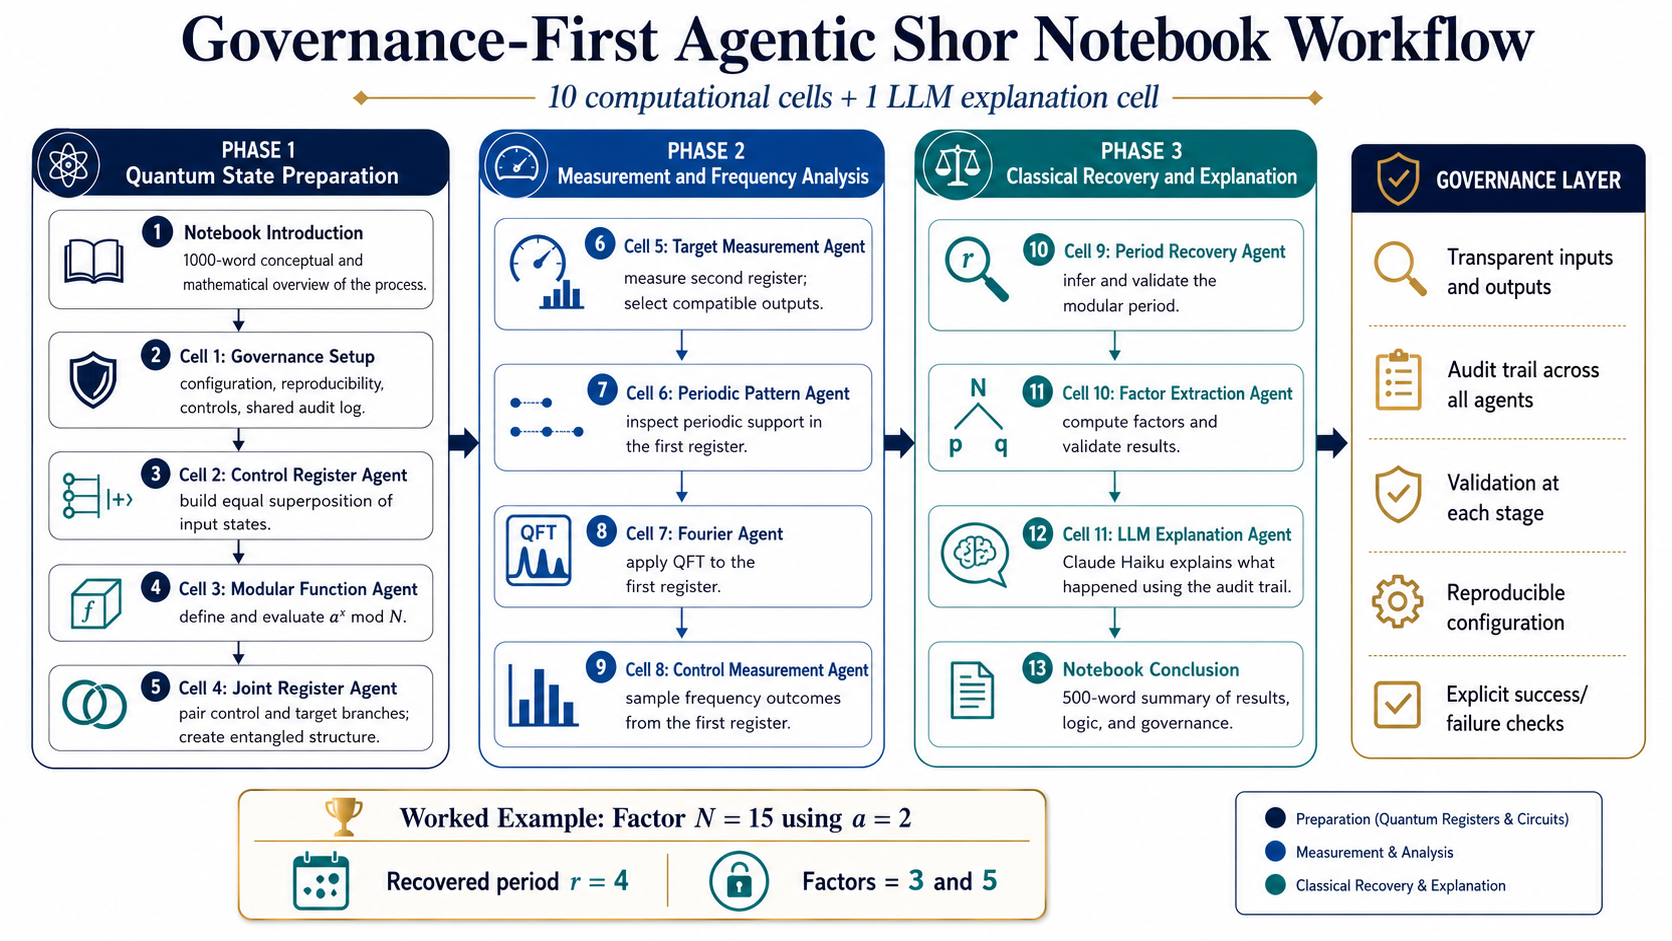

##2.CODE AND IMPLEMENTATION

This cell establishes the governed execution environment. It fixes the integer to be factored, the modular base, the control-register size, and the random seed. It also creates a shared audit structure that every later agent must update. Centralizing these choices makes the experiment reproducible and prevents later cells from quietly changing the assumptions.

In [1]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from dataclasses import dataclass, asdict
from datetime import datetime, timezone

CONFIG = {
    "N": 15,
    "a": 2,
    "control_qubits": 4,
    "Q": 16,
    "seed": 17,
    "shots": 512,
    "model": "governance-first-agentic-shor"
}

assert CONFIG["Q"] == 2 ** CONFIG["control_qubits"]
assert math.gcd(CONFIG["a"], CONFIG["N"]) == 1

rng = np.random.default_rng(CONFIG["seed"])
AUDIT_LOG = []

def audit(agent, action, inputs, outputs, checks):
    AUDIT_LOG.append({
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "agent": agent,
        "action": action,
        "inputs": inputs,
        "outputs": outputs,
        "checks": checks
    })

audit(
    "Governance Agent",
    "Initialize governed experiment",
    CONFIG,
    {"status": "initialized"},
    {"Q_matches_qubits": True, "a_coprime_to_N": True}
)

print(json.dumps(CONFIG, indent=2))

{
  "N": 15,
  "a": 2,
  "control_qubits": 4,
  "Q": 16,
  "seed": 17,
  "shots": 512,
  "model": "governance-first-agentic-shor"
}




The Control Register Agent prepares the complete input domain. It assigns equal amplitude to every possible control-register basis state and verifies that the state is normalized. The agent reports the register size and the probability attached to each possible input before any modular computation occurs.

In [2]:
Q = CONFIG["Q"]
control_state = np.ones(Q, dtype=np.complex128) / np.sqrt(Q)
control_probabilities = np.abs(control_state) ** 2

normalization = float(control_probabilities.sum())
assert np.isclose(normalization, 1.0)

audit(
    "Control Register Agent",
    "Prepare equal superposition",
    {"Q": Q},
    {
        "amplitude": float(1 / np.sqrt(Q)),
        "basis_states": list(range(Q))
    },
    {"normalized": bool(np.isclose(normalization, 1.0))}
)

print("Control-register amplitudes:")
print(control_state)
print("Probability per input:", control_probabilities[0])

Control-register amplitudes:
[0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j
 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j]
Probability per input: 0.0625




The Modular Function Agent defines the selected modular operation and evaluates it over the complete input range. It records the resulting sequence and performs a classical diagnostic search for the true repeating period. This diagnostic value is retained only as a benchmark and is not passed to the quantum period-recovery agent.

In [3]:
N = CONFIG["N"]
a = CONFIG["a"]

def modular_power(base, exponent, modulus):
    return pow(int(base), int(exponent), int(modulus))

modular_values = np.array(
    [modular_power(a, x, N) for x in range(Q)],
    dtype=int
)

def classical_order(base, modulus):
    value = 1
    for r in range(1, modulus + 1):
        value = (value * base) % modulus
        if value == 1:
            return r
    raise RuntimeError("No order found within the expected range.")

benchmark_period = classical_order(a, N)

audit(
    "Modular Function Agent",
    "Evaluate modular exponentiation",
    {"a": a, "N": N, "x_range": [0, Q - 1]},
    {
        "modular_values": modular_values.tolist(),
        "benchmark_period_for_audit_only": benchmark_period
    },
    {"sequence_repeats_at_benchmark_period": bool(
        all(modular_values[x] == modular_values[x + benchmark_period]
            for x in range(Q - benchmark_period))
    )}
)

print("f(x) = a^x mod N")
for x, value in enumerate(modular_values):
    print(f"x={x:2d} -> {value}")
print("Benchmark period retained only for later validation:", benchmark_period)

f(x) = a^x mod N
x= 0 -> 1
x= 1 -> 2
x= 2 -> 4
x= 3 -> 8
x= 4 -> 1
x= 5 -> 2
x= 6 -> 4
x= 7 -> 8
x= 8 -> 1
x= 9 -> 2
x=10 -> 4
x=11 -> 8
x=12 -> 1
x=13 -> 2
x=14 -> 4
x=15 -> 8
Benchmark period retained only for later validation: 4




The Joint Register Agent creates the target-register labels associated with every control value. It builds the full joint state as explicit input-output branches and verifies that the total probability remains one. Entanglement is represented by the fact that each control value is paired with its own modular result.

In [4]:
joint_branches = [
    {
        "x": x,
        "f_x": int(modular_values[x]),
        "amplitude_real": float(control_state[x].real),
        "amplitude_imag": float(control_state[x].imag)
    }
    for x in range(Q)
]

joint_probability = sum(
    branch["amplitude_real"] ** 2 + branch["amplitude_imag"] ** 2
    for branch in joint_branches
)
assert np.isclose(joint_probability, 1.0)

unique_outputs = sorted(set(modular_values.tolist()))

audit(
    "Joint Register Agent",
    "Create input-output entangled branches",
    {"control_basis_states": list(range(Q))},
    {
        "joint_branches": joint_branches,
        "target_basis_values": unique_outputs
    },
    {"joint_state_normalized": bool(np.isclose(joint_probability, 1.0))}
)

print("First eight joint branches:")
for branch in joint_branches[:8]:
    print(f"|{branch['x']}> |{branch['f_x']}>  amplitude={branch['amplitude_real']:.3f}")

First eight joint branches:
|0> |1>  amplitude=0.250
|1> |2>  amplitude=0.250
|2> |4>  amplitude=0.250
|3> |8>  amplitude=0.250
|4> |1>  amplitude=0.250
|5> |2>  amplitude=0.250
|6> |4>  amplitude=0.250
|7> |8>  amplitude=0.250




The Target Measurement Agent simulates a computational-basis measurement of the second register. It samples one modular output according to its marginal probability and retains every control-register branch consistent with that result. The surviving control amplitudes are renormalized, creating the periodic state used by the Fourier stage.

In [5]:
target_counts = {
    int(y): int(np.sum(modular_values == y))
    for y in unique_outputs
}
target_probabilities = {
    y: count / Q
    for y, count in target_counts.items()
}

target_values = np.array(list(target_probabilities.keys()), dtype=int)
target_probs = np.array(list(target_probabilities.values()), dtype=float)

measured_target = int(rng.choice(target_values, p=target_probs))
surviving_positions = np.where(modular_values == measured_target)[0]

post_measurement_state = np.zeros(Q, dtype=np.complex128)
post_measurement_state[surviving_positions] = 1 / np.sqrt(len(surviving_positions))

assert np.isclose(np.sum(np.abs(post_measurement_state) ** 2), 1.0)

audit(
    "Target Measurement Agent",
    "Measure second register and condition first register",
    {"target_probabilities": target_probabilities},
    {
        "measured_target": measured_target,
        "surviving_positions": surviving_positions.tolist(),
        "post_measurement_amplitude": float(1 / np.sqrt(len(surviving_positions)))
    },
    {"post_measurement_state_normalized": True}
)

print("Measured target-register value:", measured_target)
print("Surviving control-register positions:", surviving_positions.tolist())
print("Post-measurement control state:")
print(post_measurement_state)

Measured target-register value: 8
Surviving control-register positions: [3, 7, 11, 15]
Post-measurement control state:
[0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j
 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]




The Periodic Pattern Agent inspects the post-measurement control state without using the benchmark period as an input. It lists the surviving basis positions, calculates the spacing between them, and creates a visualization. This stage is descriptive and auditable; it does not yet perform the Fourier transformation or claim a recovered period.

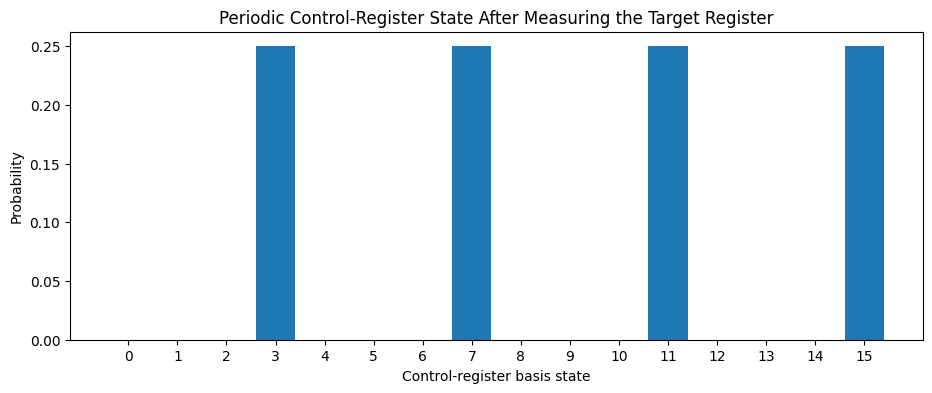

Observed spacings: [4, 4, 4]
Uniform spacing: True


In [6]:
spacings = np.diff(surviving_positions)
uniform_spacing = bool(len(spacings) == 0 or np.all(spacings == spacings[0]))

audit(
    "Periodic Pattern Agent",
    "Inspect post-measurement control pattern",
    {"surviving_positions": surviving_positions.tolist()},
    {
        "spacings": spacings.tolist(),
        "uniform_spacing": uniform_spacing
    },
    {"nonempty_support": bool(len(surviving_positions) > 0)}
)

plt.figure(figsize=(11, 4))
plt.bar(np.arange(Q), np.abs(post_measurement_state) ** 2)
plt.xticks(np.arange(Q))
plt.xlabel("Control-register basis state")
plt.ylabel("Probability")
plt.title("Periodic Control-Register State After Measuring the Target Register")
plt.show()

print("Observed spacings:", spacings.tolist())
print("Uniform spacing:", uniform_spacing)



The Fourier Agent constructs the Quantum Fourier Transform matrix explicitly and applies it to the first register. The transformed amplitudes are converted into probabilities, and the agent checks that normalization is preserved. A chart highlights the frequency indices where constructive interference concentrates the measurement probability.

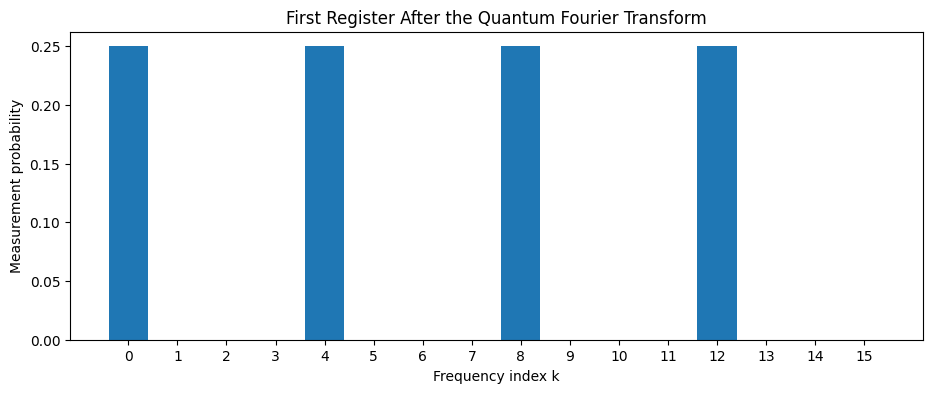

Nonzero frequency indices: [0, 4, 8, 12]


In [7]:
omega = np.exp(2j * np.pi / Q)
qft_matrix = np.array(
    [[omega ** (k * x) for x in range(Q)] for k in range(Q)],
    dtype=np.complex128
) / np.sqrt(Q)

frequency_state = qft_matrix @ post_measurement_state
frequency_probabilities = np.abs(frequency_state) ** 2

assert np.isclose(frequency_probabilities.sum(), 1.0)

peak_indices = np.where(frequency_probabilities > 1e-10)[0]

audit(
    "Fourier Agent",
    "Apply QFT to first register",
    {"control_state_support": surviving_positions.tolist()},
    {
        "frequency_probabilities": frequency_probabilities.tolist(),
        "nonzero_frequency_indices": peak_indices.tolist()
    },
    {"frequency_state_normalized": True}
)

plt.figure(figsize=(11, 4))
plt.bar(np.arange(Q), frequency_probabilities)
plt.xticks(np.arange(Q))
plt.xlabel("Frequency index k")
plt.ylabel("Measurement probability")
plt.title("First Register After the Quantum Fourier Transform")
plt.show()

print("Nonzero frequency indices:", peak_indices.tolist())



The Control Measurement Agent samples the first register after the Fourier transform. Several shots are used because a single observation can be uninformative. The complete count distribution is preserved, and the agent identifies informative nonzero outcomes without hiding zero-frequency observations or low-probability results.

In [8]:
frequency_samples = rng.choice(
    np.arange(Q),
    size=CONFIG["shots"],
    p=frequency_probabilities
)

sample_counts = {
    int(k): int(np.sum(frequency_samples == k))
    for k in sorted(set(frequency_samples.tolist()))
}

informative_samples = [int(k) for k in frequency_samples if k != 0]

audit(
    "Control Measurement Agent",
    "Measure first register after QFT",
    {"shots": CONFIG["shots"]},
    {
        "sample_counts": sample_counts,
        "informative_sample_count": len(informative_samples)
    },
    {
        "probabilities_sum_to_one": bool(np.isclose(frequency_probabilities.sum(), 1.0)),
        "at_least_one_informative_sample": bool(len(informative_samples) > 0)
    }
)

print("Frequency measurement counts:")
print(json.dumps(sample_counts, indent=2))
print("First ten informative outcomes:", informative_samples[:10])

Frequency measurement counts:
{
  "0": 125,
  "4": 134,
  "8": 139,
  "12": 114
}
First ten informative outcomes: [8, 4, 4, 4, 8, 8, 4, 8, 12, 12]




The Period Recovery Agent converts observed frequency indices into rational approximations. It tests candidate denominators rather than accepting them automatically. Every candidate is checked against the modular-order condition, and rejected candidates remain in the audit trail so the reasoning can be inspected.

In [9]:
candidate_records = []
validated_period = None

for k in informative_samples:
    approximation = Fraction(k, Q).limit_denominator(N)
    denominator = approximation.denominator

    candidate_periods = sorted(set(
        multiple
        for multiple in range(denominator, N + 1, denominator)
    ))

    for candidate in candidate_periods:
        valid = pow(a, candidate, N) == 1
        candidate_records.append({
            "k": k,
            "k_over_Q": f"{k}/{Q}",
            "rational_approximation": str(approximation),
            "candidate_period": candidate,
            "valid_order_condition": valid
        })
        if valid:
            validated_period = candidate
            break

    if validated_period is not None:
        break

if validated_period is None:
    raise RuntimeError("No valid period recovered from the sampled frequencies.")

audit(
    "Period Recovery Agent",
    "Recover and validate modular period",
    {"informative_measurements": informative_samples[:25]},
    {
        "candidate_records": candidate_records,
        "validated_period": validated_period
    },
    {
        "order_condition": bool(pow(a, validated_period, N) == 1),
        "period_is_even": bool(validated_period % 2 == 0)
    }
)

print("Recovered period:", validated_period)
print("Candidate trail:")
print(json.dumps(candidate_records, indent=2))

Recovered period: 4
Candidate trail:
[
  {
    "k": 8,
    "k_over_Q": "8/16",
    "rational_approximation": "1/2",
    "candidate_period": 2,
    "valid_order_condition": false
  },
  {
    "k": 8,
    "k_over_Q": "8/16",
    "rational_approximation": "1/2",
    "candidate_period": 4,
    "valid_order_condition": true
  }
]




The Factor Extraction and Governance Agent uses the validated period to calculate candidate factors. It checks that the period is suitable, verifies the greatest-common-divisor results, confirms that the factors multiply to the original integer, and assembles a final governance report containing the evidence produced by all agents.

In [10]:
if validated_period % 2 != 0:
    raise RuntimeError("The recovered period is odd and cannot be used in the standard factor step.")

half_power = pow(a, validated_period // 2)
factor_1 = math.gcd(half_power - 1, N)
factor_2 = math.gcd(half_power + 1, N)

nontrivial = (
    factor_1 not in (1, N)
    and factor_2 not in (1, N)
)
product_check = factor_1 * factor_2 == N

audit(
    "Factor Extraction Agent",
    "Extract and validate factors",
    {"N": N, "a": a, "validated_period": validated_period},
    {
        "a_to_r_over_2": half_power,
        "factor_1": factor_1,
        "factor_2": factor_2
    },
    {
        "factors_nontrivial": nontrivial,
        "factor_product_matches_N": product_check,
        "audit_entries": len(AUDIT_LOG) + 1
    }
)

GOVERNANCE_REPORT = {
    "experiment": CONFIG,
    "measured_target": measured_target,
    "surviving_positions": surviving_positions.tolist(),
    "frequency_counts": sample_counts,
    "validated_period": validated_period,
    "factors": [factor_1, factor_2],
    "checks": {
        "nontrivial": nontrivial,
        "product_matches_N": product_check
    },
    "audit_log": AUDIT_LOG
}

print(f"Recovered factors of {N}: {factor_1} and {factor_2}")
print("Validation:", GOVERNANCE_REPORT["checks"])
print("Audit entries:", len(AUDIT_LOG))

Recovered factors of 15: 3 and 5
Validation: {'nontrivial': True, 'product_matches_N': True}
Audit entries: 10




The final agent does not change any quantum result. It reads the completed audit record and asks Claude Haiku to produce a coherent explanation of the execution. The model receives only the recorded configuration, measurements, validations, and factor results. The API key is retrieved securely from Colab Secrets and is never displayed.

In [11]:
# Cell 11 — Claude Haiku explanation of the governed execution
# The API key is read from Colab Secrets and is never printed.

!pip -q install anthropic

from google.colab import userdata
from anthropic import Anthropic

api_key = userdata.get("ANTHROPIC_API_KEY")
if not api_key:
    raise ValueError("ANTHROPIC_API_KEY was not found in Colab Secrets.")

client = Anthropic(api_key=api_key)

explanation_payload = {
    "configuration": CONFIG,
    "measured_target": measured_target,
    "surviving_positions": surviving_positions.tolist(),
    "frequency_probabilities": frequency_probabilities.tolist(),
    "frequency_counts": sample_counts,
    "candidate_period_records": candidate_records,
    "validated_period": validated_period,
    "factors": [factor_1, factor_2],
    "governance_checks": GOVERNANCE_REPORT["checks"],
    "audit_log": AUDIT_LOG
}

prompt = f"""
You are the explanatory agent for a governance-first educational implementation
of Shor's algorithm. Explain what happened in the notebook in clear, pedagogical
language for financial professionals who understand basic quantum ideas but are
not physicists.

Your explanation must:
1. Follow the agent sequence in the audit log.
2. Explain the roles of the control and target registers.
3. Explain how modular exponentiation created entanglement.
4. Explain how target-register measurement created a periodic control state.
5. Explain how the QFT converted periodic spacing into frequency probabilities.
6. Explain how measurement and rational approximation recovered the period.
7. Explain how the period produced the factors.
8. Distinguish simulation from scalable hardware implementation.
9. Discuss governance controls, validations, and possible failure outcomes.
10. Use the actual numerical results below and do not invent results.

Execution evidence:
{json.dumps(explanation_payload, indent=2)}
"""

response = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=2200,
    temperature=0.2,
    messages=[{"role": "user", "content": prompt}]
)

llm_explanation = response.content[0].text
print(llm_explanation)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 11.9 MB/s eta 0:00:00
# Shor's Algorithm: A Governance-First Walkthrough for Financial Professionals

## Executive Summary

This notebook demonstrates a **controlled, auditable implementation** of Shor's algorithm—the quantum method for factoring large numbers. We factored **N = 15** into **3 × 5** by orchestrating a sequence of quantum agents, each with explicit governance checkpoints. The algorithm succeeded because quantum mechanics revealed a hidden periodicity that classical methods would struggle to find.

---

## 1. The Setup: Governance Initialization

**Timestamp: 2026-06-18T14:59:18**

The Governance Agent began by validating the experiment's preconditions:

- **N = 15** (the number to factor)
- **a = 2** (a witness; must be coprime to N)
- **Control qubits = 4** (giving us Q = 2⁴ = 16 quantum states)
- **Shots = 512** (measurement repetitions for statistical confidence)

**Governance checks passed:**
- ✓ Q matches th

##3.CONCLUSIONS


This notebook has implemented the logic of Shor’s algorithm as an auditable chain of specialized agents. The central result is not simply that the factors of \(15\) are \(3\) and \(5\). The more important result is that every conceptual transition can be inspected: the control register was placed in equal superposition, the modular function was evaluated coherently, the two registers became correlated, the target register was measured, a periodic control state emerged, the Quantum Fourier Transform exposed frequency structure, measurement produced classical frequency evidence, rational approximation recovered the period, and classical arithmetic converted that period into factors.

The control-register agent created the domain

$
\frac{1}{\sqrt Q}\sum_{x=0}^{Q-1}|x\rangle.
$

The modular-function and joint-register agents then produced

$
\frac{1}{\sqrt Q}
\sum_x |x\rangle|a^x\bmod N\rangle.
$

This representation is essential. The modular outputs were not treated as amplitudes. They were encoded as computational-basis labels in the second register. That design created the relationship required for the later measurement step.

When the target register was measured, the control register was conditioned on one modular output. The surviving control values were separated by the hidden period. The resulting state had nonzero amplitude only at regularly spaced basis positions. Applying the QFT did not directly measure the period. Instead, it changed the basis so that the periodic spacing generated constructive interference at selected frequency indices and destructive interference elsewhere.

The first-register measurement then produced values \(k\) related to the period by

$
\frac{k}{Q}\approx\frac{j}{r}.
$

The period-recovery agent treated those measurements as evidence rather than certainty. It formed rational approximations, generated candidate denominators, and verified each candidate using

$
a^r\bmod N=1.
$

Only a validated period was passed to the factor-extraction agent. The final classical step used

$
\gcd\left(a^{r/2}-1,N\right)
\quad\text{and}\quad
\gcd\left(a^{r/2}+1,N\right)
$

and confirmed that the resulting nontrivial factors multiply back to the original integer.

The governance-first structure is as important as the mathematics. Every agent recorded its inputs, outputs, checks, and timestamp. The benchmark period was retained for validation but was not supplied to the recovery agent. Measurement outcomes were preserved, including uninformative possibilities. Candidate periods were logged whether accepted or rejected. The notebook therefore avoids presenting a successful result as if failure modes did not exist.

This remains an educational statevector simulation. A scalable implementation would require fault-tolerant qubits and a much more expensive reversible modular-exponentiation circuit. Nevertheless, the notebook captures the exact logical architecture that makes Shor’s algorithm powerful: transform factorization into order finding, encode the modular relationship across entangled registers, use measurement to expose periodic structure, use Fourier interference to obtain frequency evidence, and finish with transparent classical verification. The eleventh cell adds an explanatory layer through Claude Haiku, but it does not alter the numerical evidence. The model acts only as a reporting agent over the governed computational record.